In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv('ECGArrhythmia.csv')

df.head()

,record,type,0_pre-RR,0_post-RR,0_pPeak,0_tPeak,0_rPeak,0_sPeak,0_qPeak,0_qrs_interval,...,1_qPeak,1_qrs_interval,1_pq_interval,1_qt_interval,1_st_interval,1_qrs_morph0,1_qrs_morph1,1_qrs_morph2,1_qrs_morph3,1_qrs_morph4
0,I01,N,163,165,0.069610,-0.083281,0.614133,-0.392761,0.047159,15,...,-0.023370,14,3,23,6,-0.023370,-0.011650,0.082608,0.101373,-0.183387
1,I01,N,165,166,-0.097030,0.597254,-0.078704,-0.078704,-0.137781,3,...,0.081637,15,5,27,7,0.081637,0.102992,0.191225,0.217544,-0.068248
2,I01,N,166,102,0.109399,0.680528,-0.010649,-0.010649,-0.720620,6,...,-0.148539,33,13,52,6,-0.148539,-0.060620,0.081080,0.204400,0.335172
3,I01,VEB,102,231,0.176376,0.256431,-0.101098,-0.707525,-0.101098,4,...,0.046898,21,9,34,4,0.046898,0.083728,0.279512,0.526785,0.450969
4,I01,N,231,165,0.585577,0.607461,-0.083499,-0.083499,-0.167858,3,...,-0.112552,32,5,43,6,-0.112552,0.012989,0.091491,0.134004,0.265232


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 175729 entries, 0 to 175728
Data columns (total 34 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   record          175729 non-null  object 
 1   type            175729 non-null  object 
 2   0_pre-RR        175729 non-null  int64  
 3   0_post-RR       175729 non-null  int64  
 4   0_pPeak         175729 non-null  float64
 5   0_tPeak         175729 non-null  float64
 6   0_rPeak         175729 non-null  float64
 7   0_sPeak         175729 non-null  float64
 8   0_qPeak         175729 non-null  float64
 9   0_qrs_interval  175729 non-null  int64  
 10  0_pq_interval   175729 non-null  int64  
 11  0_qt_interval   175729 non-null  int64  
 12  0_st_interval   175729 non-null  int64  
 13  0_qrs_morph0    175729 non-null  float64
 14  0_qrs_morph1    175729 non-null  float64
 15  0_qrs_morph2    175729 non-null  float64
 16  0_qrs_morph3    175729 non-null  float64
 17  0_qrs_morp

In [4]:
# Exploratory Data Analysis (EDA)

import matplotlib.pyplot as plt

eda_df = df.copy()


# 1) Dataset overview
print("Dataset shape:", eda_df.shape)
print("Number of patients:", eda_df["record"].nunique())
print("Missing values:", eda_df.isnull().sum().sum())

print("\nECG classes:")
print(eda_df["type"].value_counts())

Dataset shape: (175729, 34)
Number of patients: 75
Missing values: 0

ECG classes:
type
N       153546
VEB      20000
SVEB      1958
F          219
Q            6
Name: count, dtype: int64


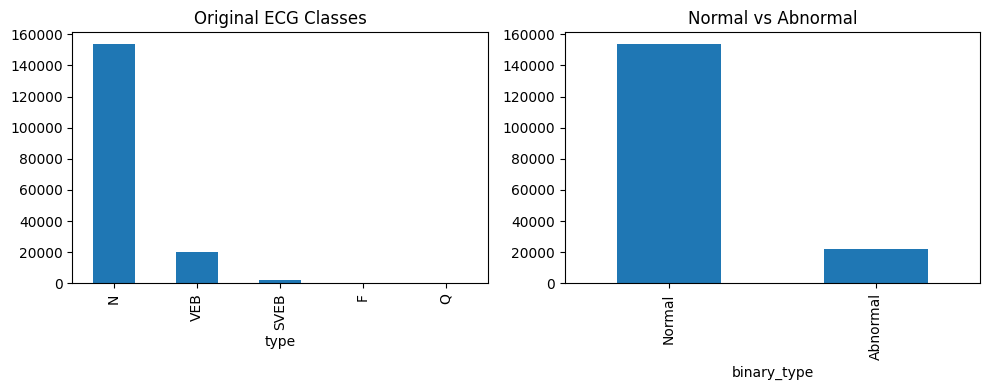

In [5]:
# 2) Class distribution

eda_df["binary_type"] = eda_df["type"].map({
    "N": "Normal",
    "VEB": "Abnormal",
    "SVEB": "Abnormal",
    "F": "Abnormal",
    "Q": "Abnormal"
})

fig, ax = plt.subplots(1, 2, figsize=(10, 4))

eda_df["type"].value_counts().plot(
    kind="bar",
    ax=ax[0],
    title="Original ECG Classes"
)

eda_df["binary_type"].value_counts().plot(
    kind="bar",
    ax=ax[1],
    title="Normal vs Abnormal"
)

plt.tight_layout()
plt.show()

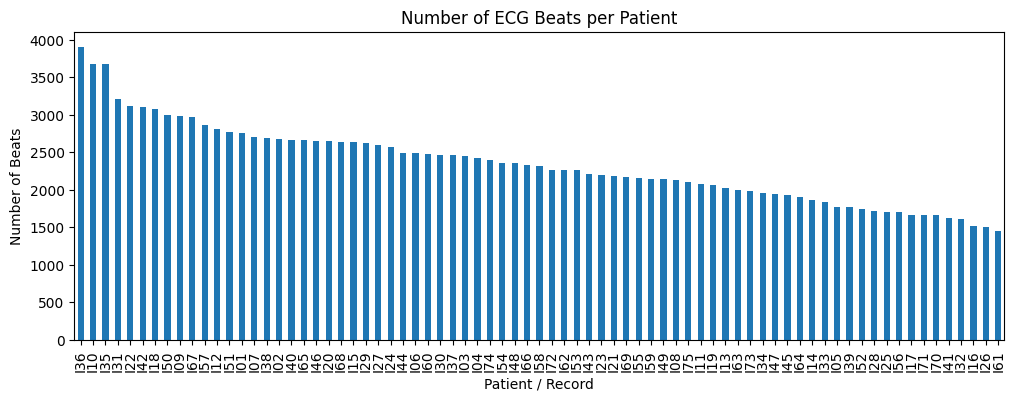

In [6]:
# 3) Number of beats per patient

beats_per_patient = eda_df["record"].value_counts()

beats_per_patient.plot(
    kind="bar",
    figsize=(12, 4),
    title="Number of ECG Beats per Patient"
)

plt.xlabel("Patient / Record")
plt.ylabel("Number of Beats")
plt.show()

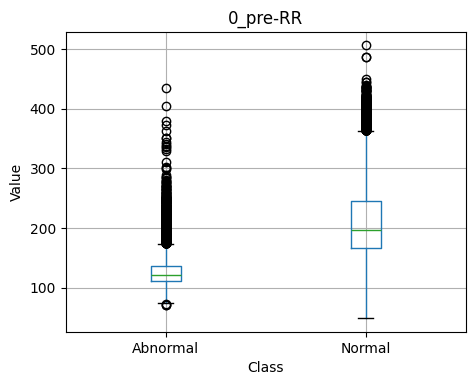

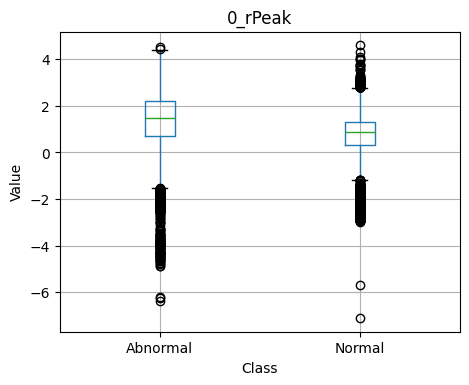

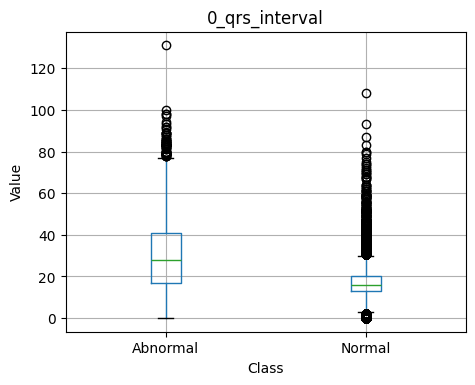

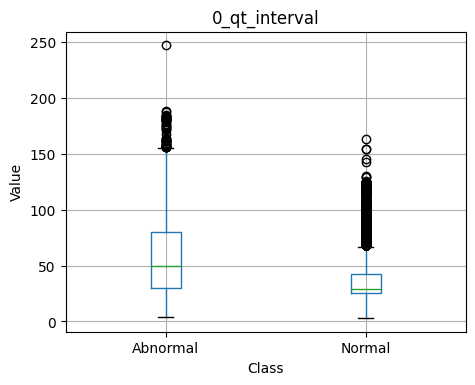

In [7]:
# 4) Compare important ECG features

features = [
    "0_pre-RR",
    "0_rPeak",
    "0_qrs_interval",
    "0_qt_interval"
]

for feature in features:
    eda_df.boxplot(
        column=feature,
        by="binary_type",
        figsize=(5, 4)
    )

    plt.title(feature)
    plt.suptitle("")
    plt.xlabel("Class")
    plt.ylabel("Value")
    plt.show()

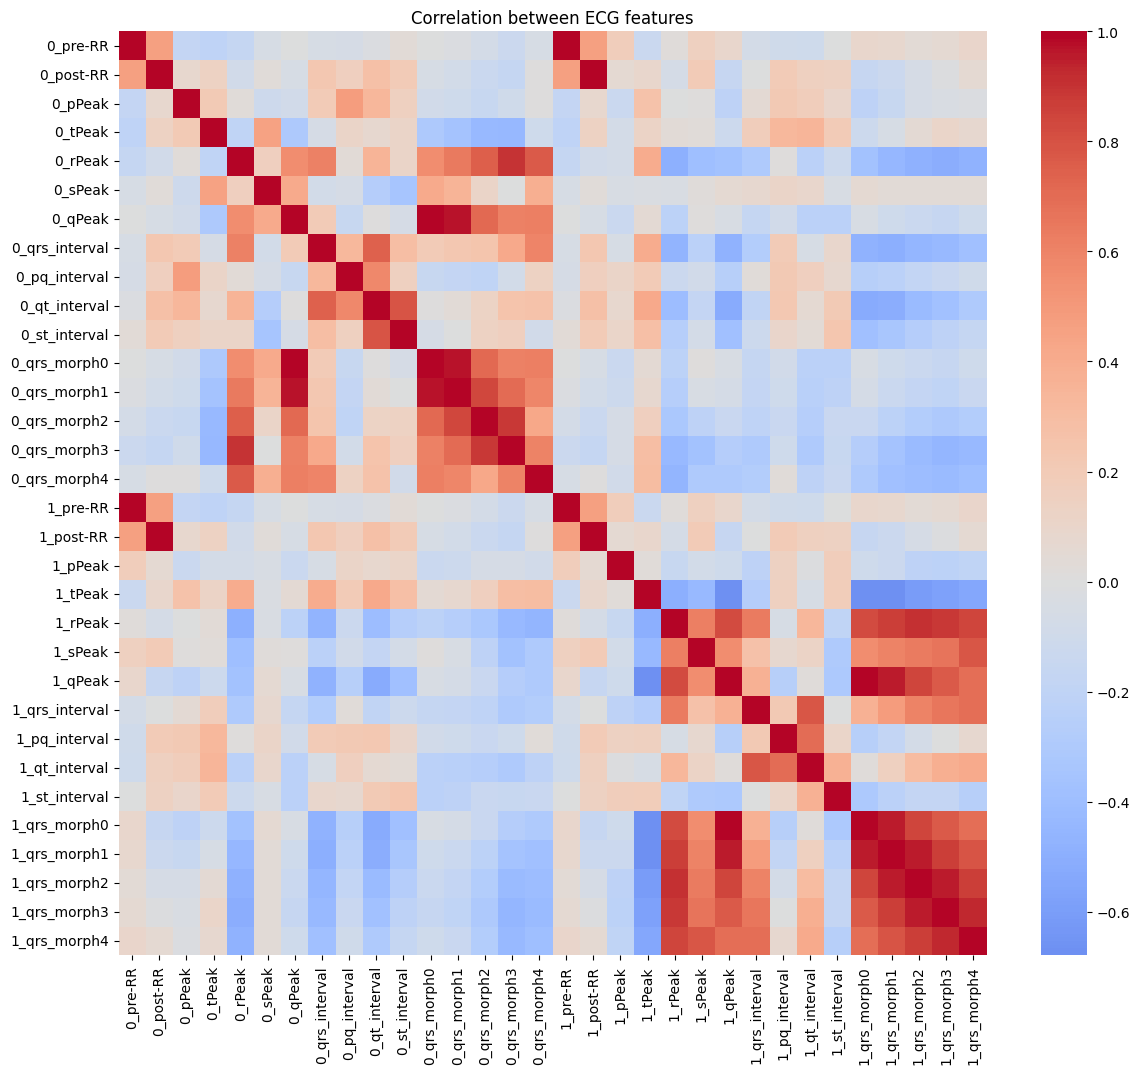

In [8]:
import seaborn as sns

# Select features from both ECG leads
lead_II = df.filter(regex="^0_")
lead_V5 = df.filter(regex="^1_")

all_lead_features = pd.concat([lead_II, lead_V5], axis=1)

# Correlation
corr = all_lead_features.corr()

plt.figure(figsize=(14, 12))
sns.heatmap(corr, cmap="coolwarm", center=0)

plt.title("Correlation between ECG features")
plt.show()

In [ ]:
# Check correlations higher than 90%
corr_pairs = corr.abs().unstack()

high_corr = corr_pairs[
    (corr_pairs > 0.9) &
    (corr_pairs < 1.0)
]

print(high_corr.sort_values(ascending=False).head(30))

0_qPeak       0_qrs_morph1    0.968084
0_qrs_morph0  0_qrs_morph1    0.968084
0_qrs_morph1  0_qPeak         0.968084
              0_qrs_morph0    0.968084
1_qrs_morph2  1_qrs_morph3    0.960590
1_qrs_morph3  1_qrs_morph2    0.960590
1_qrs_morph1  1_qrs_morph2    0.949645
1_qrs_morph2  1_qrs_morph1    0.949645
1_qPeak       1_qrs_morph1    0.947705
1_qrs_morph0  1_qrs_morph1    0.947705
1_qrs_morph1  1_qPeak         0.947705
              1_qrs_morph0    0.947705
1_qrs_morph3  1_qrs_morph4    0.929168
1_qrs_morph4  1_qrs_morph3    0.929168
1_rPeak       1_qrs_morph2    0.904017
1_qrs_morph2  1_rPeak         0.904017
dtype: float64


In [10]:
# X = the actual features for ECG
# "record" should not be part of the features
X = df.drop(["record", "type"], axis=1)

# Binary target:
# 0 = Normal
# 1 = Abnormal
y = df["type"].map({
    "N": 0,
    "VEB": 1,
    "SVEB": 1,
    "F": 1,
    "Q": 1
})

# groups used just for split
groups = df["record"]


y.value_counts(normalize=True) * 100

type
0    87.376586
1    12.623414
Name: proportion, dtype: float64

### Train-Test Split Limitation

The dataset contains records from a limited number of patients. 
Therefore, the test performance may depend on which patients are included in the test set.

To reduce data leakage, the split is performed at the patient/record level using `StratifiedGroupKFold`, ensuring that records from the same patient do not appear in both training and test sets.

In [11]:
# 1) Split data by patient/record
from sklearn.model_selection import StratifiedGroupKFold, GridSearchCV

split = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=1
)

train_idx, test_idx = next(
    split.split(X, y, groups=groups)
)

X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]

y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

groups_train = groups.iloc[train_idx]
groups_test = groups.iloc[test_idx]


# Check that train and test do not share the same patient
common_records = set(groups_train) & set(groups_test)

print("Common records:", common_records)
print("Train records:", groups_train.nunique())
print("Test records:", groups_test.nunique())

assert len(common_records) == 0


Common records: set()
Train records: 59
Test records: 16


In [12]:
# Remove highly correlated features

corr = X_train.corr().abs()

to_drop = set()

for i in range(len(corr.columns)):
    for j in range(i):
        if corr.iloc[i, j] > 0.90:
            to_drop.add(corr.columns[i])

print("Features to drop:")
print(to_drop)

X_train = X_train.drop(columns=list(to_drop))
X_test = X_test.drop(columns=list(to_drop))

print("Remaining features:", X_train.shape[1])

Features to drop:
{'1_post-RR', '0_qrs_morph1', '1_qrs_morph4', '1_qrs_morph1', '1_qrs_morph3', '0_qrs_morph3', '1_pre-RR', '0_qrs_morph0', '1_qrs_morph0', '1_qrs_morph2'}
Remaining features: 22


In [13]:

# Check percentage of outliers in each class

for col in features:

    Q1 = X_train[col].quantile(0.25)
    Q3 = X_train[col].quantile(0.75)
    IQR = Q3 - Q1

    mask = (
        (X_train[col] < Q1 - 1.5 * IQR) |
        (X_train[col] > Q3 + 1.5 * IQR)
    )

    print("\n", col)

    for cls in [0, 1]:
        total = (y_train == cls).sum()
        outlier_count = ((y_train == cls) & mask).sum()

        print(
            "Class", cls,
            ":",
            round(outlier_count / total * 100, 2),
            "%"
        )


 0_pre-RR
Class 0 : 1.13 %
Class 1 : 0.04 %

 0_rPeak
Class 0 : 2.19 %
Class 1 : 8.16 %

 0_qrs_interval
Class 0 : 6.43 %
Class 1 : 39.84 %

 0_qt_interval
Class 0 : 4.38 %
Class 1 : 28.49 %


In [ ]:
# Decision Tree 

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score
)

from imblearn.over_sampling import RandomOverSampler
from imblearn.pipeline import Pipeline


# 2) Pipeline: balance training data, then Decision Tree
dt_pipe = Pipeline([
    ("ros", RandomOverSampler(random_state=1)),
    ("tree", DecisionTreeClassifier(
        criterion="gini",
        random_state=1
    ))
])


# 3) Parameters for tuning
dt_param_grid = {
    "tree__max_depth": [5, 10, 20, None],
    "tree__min_samples_split": [2, 10],
    "tree__min_samples_leaf": [1, 5]
}


# 4) Cross-validation by patient/record
cv = StratifiedGroupKFold(
    n_splits=3,
    shuffle=True,
    random_state=1
)


# 5) Hyperparameter tuning
dt_grid = GridSearchCV(
    estimator=dt_pipe,
    param_grid=dt_param_grid,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

dt_grid.fit(
    X_train,
    y_train,
    groups=groups_train
)


# 6) Best model
best_dt_model = dt_grid.best_estimator_


# 7) Predictions
y_pred_dt = best_dt_model.predict(X_test)
y_train_pred_dt = best_dt_model.predict(X_train)
y_proba_dt = best_dt_model.predict_proba(X_test)[:, 1]


# 8) Results
print("\nBest parameters:", dt_grid.best_params_)
print("Best CV F1:", dt_grid.best_score_)

print("\nTrain F1:", f1_score(y_train, y_train_pred_dt))

print("\nTest results")
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt, zero_division=0))
print("Recall:", recall_score(y_test, y_pred_dt, zero_division=0))
print("F1:", f1_score(y_test, y_pred_dt, zero_division=0))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_dt))

results_dt = {
    "Model": "Decision Tree",
    "Train F1": f1_score(y_train, y_train_pred_dt),
    "CV F1": dt_grid.best_score_,
    "Test F1": f1_score(y_test, y_pred_dt, zero_division=0),
    "Precision": precision_score(y_test, y_pred_dt, zero_division=0),
    "Recall": recall_score(y_test, y_pred_dt, zero_division=0),
    "ROC-AUC": roc_auc_score(y_test, y_proba_dt)
}

Fitting 3 folds for each of 16 candidates, totalling 48 fits


/Users/eli/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:484: FutureWarning: `BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.
  warnings.warn(
/Users/eli/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:493: FutureWarning: `BaseEstimator._check_feature_names` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_feature_names` instead.
  warnings.warn(
/Users/eli/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:484: FutureWarning: `BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.
  warnings.warn(
/Users/eli/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:493: FutureWarning: `BaseEstimator._check_feature_names` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_feature_names` instead.
  warning


Best parameters: {'tree__max_depth': 5, 'tree__min_samples_leaf': 1, 'tree__min_samples_split': 2}
Best CV F1: 0.8301373922416381

Train F1: 0.9246904355251921

Test results
Accuracy: 0.9678611602121163
Precision: 0.78364060182242
Recall: 0.9538302811452154
F1: 0.8604001861330851

Confusion Matrix:
[[32440  1021]
 [  179  3698]]


In [15]:
# KNN

from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import MinMaxScaler

# 1) Pipeline: scale, balance, then KNN
knn_pipe = Pipeline([
    ("scale", MinMaxScaler()),
    ("ros", RandomOverSampler(random_state=1)),
    ("knn", KNeighborsClassifier())
])

# 2) Values of K to test
knn_param_grid = {
    "knn__n_neighbors": [51, 75, 101, 125, 151]
}


# 3) Cross-validation by patient/record
cv = StratifiedGroupKFold(
    n_splits=3,
    shuffle=True,
    random_state=1
)


# 4) Hyperparameter tuning
knn_grid = GridSearchCV(
    estimator=knn_pipe,
    param_grid=knn_param_grid,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

knn_grid.fit(
    X_train,
    y_train,
    groups=groups_train
)


# 5) Best model
best_knn_model = knn_grid.best_estimator_


# 6) Prediction
y_pred_knn = best_knn_model.predict(X_test)
y_proba_knn = best_knn_model.predict_proba(X_test)[:, 1]


# 7) Results

print("\nBest parameters:", knn_grid.best_params_)
print("Best CV F1:", knn_grid.best_score_)

print("\nTest results")
print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print("Precision:", precision_score(y_test, y_pred_knn, zero_division=0))
print("Recall:", recall_score(y_test, y_pred_knn, zero_division=0))
print("F1:", f1_score(y_test, y_pred_knn, zero_division=0))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_knn))

# 9) check overfitting with F1 on train
y_train_pred = best_knn_model.predict(X_train)

print(
    "Train F1:",
    f1_score(y_train, y_train_pred)
)

results_knn = {
    "Model": "KNN",
    "Train F1": f1_score(y_train, y_train_pred),
    "CV F1": knn_grid.best_score_,
    "Test F1": f1_score(y_test, y_pred_knn, zero_division=0),
    "Precision": precision_score(y_test, y_pred_knn, zero_division=0),
    "Recall": recall_score(y_test, y_pred_knn, zero_division=0),
    "ROC-AUC": roc_auc_score(y_test, y_proba_knn)
}

Fitting 3 folds for each of 5 candidates, totalling 15 fits


/Users/eli/Library/Python/3.9/lib/python/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/eli/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:484: FutureWarning: `BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.
  warnings.warn(
/Users/eli/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:493: FutureWarning: `BaseEstimator._check_feature_names` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_feature_names` instead.
  warnings.warn(
/Users/eli/Library/Python/3.9/lib/python/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/eli/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:484: 


Best parameters: {'knn__n_neighbors': 125}
Best CV F1: 0.9337830637859391

Test results
Accuracy: 0.9927687610477262
Precision: 0.9543965734441925
Recall: 0.9770441062677327
F1: 0.9655875605404027

Confusion Matrix:
[[33280   181]
 [   89  3788]]
Train F1: 0.9766999782750381


In [ ]:
# Logistic Regression

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler



# 1) Pipeline: scale, balance, then Logistic Regression
log_pipe = Pipeline([
    ("scale", StandardScaler()),
    ("ros", RandomOverSampler(random_state=1)),
    ("logreg", LogisticRegression(
        max_iter=1000,
        random_state=1
    ))
])


# 2) Parameters for tuning
log_param_grid = {
    "logreg__C": [0.01, 0.1, 1, 10, 100]
}


# 3) Cross-validation by patient/record
cv = StratifiedGroupKFold(
    n_splits=3,
    shuffle=True,
    random_state=1
)


# 4) Hyperparameter tuning
log_grid = GridSearchCV(
    estimator=log_pipe,
    param_grid=log_param_grid,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    verbose=1
)


log_grid.fit(
    X_train,
    y_train,
    groups=groups_train
)


# 5) Best model
best_log_model = log_grid.best_estimator_


# 6) Predictions
y_pred_log = best_log_model.predict(X_test)
y_train_pred_log = best_log_model.predict(X_train)
y_proba_log = best_log_model.predict_proba(X_test)[:, 1]


# 7) Results
print("\nBest parameters:", log_grid.best_params_)
print("Best CV F1:", log_grid.best_score_)

print("\nTrain F1:", f1_score(y_train, y_train_pred_log))

print("\nTest results")
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("Precision:", precision_score(y_test, y_pred_log, zero_division=0))
print("Recall:", recall_score(y_test, y_pred_log, zero_division=0))
print("F1:", f1_score(y_test, y_pred_log, zero_division=0))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_log))

results_log = {
    "Model": "Logistic Regression",
    "Train F1": f1_score(y_train, y_train_pred_log),
    "CV F1": log_grid.best_score_,
    "Test F1": f1_score(y_test, y_pred_log, zero_division=0),
    "Precision": precision_score(y_test, y_pred_log, zero_division=0),
    "Recall": recall_score(y_test, y_pred_log, zero_division=0),
    "ROC-AUC": roc_auc_score(y_test, y_proba_log)
}

Fitting 3 folds for each of 5 candidates, totalling 15 fits


/Users/eli/Library/Python/3.9/lib/python/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/eli/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:484: FutureWarning: `BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.
  warnings.warn(
/Users/eli/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:493: FutureWarning: `BaseEstimator._check_feature_names` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_feature_names` instead.
  warnings.warn(
/Users/eli/Library/Python/3.9/lib/python/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/eli/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:484: 


Best parameters: {'logreg__C': 0.01}
Best CV F1: 0.877624825979438

Train F1: 0.9289773478180424

Test results
Accuracy: 0.9879479350795436
Precision: 0.9051785292031213
Recall: 0.9873613618777405
F1: 0.9444855662472242

Confusion Matrix:
[[33060   401]
 [   49  3828]]


/Users/eli/Library/Python/3.9/lib/python/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/eli/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:484: FutureWarning: `BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.
  warnings.warn(
/Users/eli/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:493: FutureWarning: `BaseEstimator._check_feature_names` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_feature_names` instead.
  warnings.warn(
/Users/eli/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/eli/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:2

In [17]:
# Naive bayes

from sklearn.naive_bayes import GaussianNB

# 1) Pipeline: balance training data, then Naive Bayes
nb_pipe = Pipeline([
    ("ros", RandomOverSampler(random_state=1)),
    ("nb", GaussianNB())
])


# 2) Parameters for tuning
nb_param_grid = {
    "nb__var_smoothing": [1e-11, 1e-10, 1e-9, 1e-8, 1e-7]
}


# 3) Cross-validation by patient/record
cv = StratifiedGroupKFold(
    n_splits=3,
    shuffle=True,
    random_state=1
)


# 4) Hyperparameter tuning
nb_grid = GridSearchCV(
    estimator=nb_pipe,
    param_grid=nb_param_grid,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    verbose=1
)


# 5) Train and tune
nb_grid.fit(
    X_train,
    y_train,
    groups=groups_train
)


# 6) Best model
best_nb_model = nb_grid.best_estimator_


# 7) Predictions
y_pred_nb = best_nb_model.predict(X_test)
y_train_pred_nb = best_nb_model.predict(X_train)
y_proba_nb = best_nb_model.predict_proba(X_test)[:, 1]


# 8) Results
print("\nBest parameters:", nb_grid.best_params_)
print("Best CV F1:", nb_grid.best_score_)

print("\nTrain F1:", f1_score(y_train, y_train_pred_nb))

print("\nTest results")
print("Accuracy:", accuracy_score(y_test, y_pred_nb))
print("Precision:", precision_score(y_test, y_pred_nb, zero_division=0))
print("Recall:", recall_score(y_test, y_pred_nb, zero_division=0))
print("F1:", f1_score(y_test, y_pred_nb, zero_division=0))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_nb))

results_nb = {
    "Model": "Naive Bayes",
    "Train F1": f1_score(y_train, y_train_pred_nb),
    "CV F1": nb_grid.best_score_,
    "Test F1": f1_score(y_test, y_pred_nb, zero_division=0),
    "Precision": precision_score(y_test, y_pred_nb, zero_division=0),
    "Recall": recall_score(y_test, y_pred_nb, zero_division=0),
    "ROC-AUC": roc_auc_score(y_test, y_proba_nb)
}

Fitting 3 folds for each of 5 candidates, totalling 15 fits


/Users/eli/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:484: FutureWarning: `BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.
  warnings.warn(
/Users/eli/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:493: FutureWarning: `BaseEstimator._check_feature_names` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_feature_names` instead.
  warnings.warn(
/Users/eli/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:484: FutureWarning: `BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.
  warnings.warn(
/Users/eli/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:493: FutureWarning: `BaseEstimator._check_feature_names` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_feature_names` instead.
  warning


Best parameters: {'nb__var_smoothing': 1e-07}
Best CV F1: 0.704661939317836

Train F1: 0.7440450845335003

Test results
Accuracy: 0.9819486849858053
Precision: 0.9107463452167223
Recall: 0.915914366778437
F1: 0.9133230452674898

Confusion Matrix:
[[33113   348]
 [  326  3551]]


/Users/eli/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:484: FutureWarning: `BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.
  warnings.warn(
/Users/eli/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:493: FutureWarning: `BaseEstimator._check_feature_names` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_feature_names` instead.
  warnings.warn(


In [18]:
# Random forest 

from sklearn.ensemble import RandomForestClassifier


# 1) Pipeline: balance training data, then Random Forest
rf_pipe = Pipeline([
    ("ros", RandomOverSampler(random_state=1)),
    ("rf", RandomForestClassifier(
        random_state=1,
        n_jobs=1
    ))
])


# 2) Parameters for tuning
rf_param_grid = {
    "rf__n_estimators": [100],
    "rf__max_depth": [10, 20, None],
    "rf__min_samples_split": [2],
    "rf__min_samples_leaf": [1, 5]
}


# 3) Cross-validation by patient/record
cv = StratifiedGroupKFold(
    n_splits=3,
    shuffle=True,
    random_state=1
)


# 4) Hyperparameter tuning
rf_grid = GridSearchCV(
    estimator=rf_pipe,
    param_grid=rf_param_grid,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    verbose=1
)


# 5) Train and tune
rf_grid.fit(
    X_train,
    y_train,
    groups=groups_train
)


# 6) Best model
best_rf_model = rf_grid.best_estimator_


# 7) Predictions
y_pred_rf = best_rf_model.predict(X_test)
y_train_pred_rf = best_rf_model.predict(X_train)
y_proba_rf = best_rf_model.predict_proba(X_test)[:, 1]


# 8) Results
print("\nBest parameters:", rf_grid.best_params_)
print("Best CV F1:", rf_grid.best_score_)

print("\nTrain F1:", f1_score(y_train, y_train_pred_rf))

print("\nTest results")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf, zero_division=0))
print("Recall:", recall_score(y_test, y_pred_rf, zero_division=0))
print("F1:", f1_score(y_test, y_pred_rf, zero_division=0))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

results_rf = {
    "Model": "Random Forest",
    "Train F1": f1_score(y_train, y_train_pred_rf),
    "CV F1": rf_grid.best_score_,
    "Test F1": f1_score(y_test, y_pred_rf, zero_division=0),
    "Precision": precision_score(y_test, y_pred_rf, zero_division=0),
    "Recall": recall_score(y_test, y_pred_rf, zero_division=0),
    "ROC-AUC": roc_auc_score(y_test, y_proba_rf)
}

Fitting 3 folds for each of 6 candidates, totalling 18 fits


/Users/eli/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:484: FutureWarning: `BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.
  warnings.warn(
/Users/eli/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:493: FutureWarning: `BaseEstimator._check_feature_names` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_feature_names` instead.
  warnings.warn(
/Users/eli/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:484: FutureWarning: `BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.
  warnings.warn(
/Users/eli/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:493: FutureWarning: `BaseEstimator._check_feature_names` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_feature_names` instead.
  warning


Best parameters: {'rf__max_depth': 20, 'rf__min_samples_leaf': 1, 'rf__min_samples_split': 2, 'rf__n_estimators': 100}
Best CV F1: 0.9039476290241585

Train F1: 0.9994535220503853

Test results
Accuracy: 0.9927687610477262
Precision: 0.9592564298446652
Recall: 0.9716275470724787
F1: 0.9654023577652486

Confusion Matrix:
[[33301   160]
 [  110  3767]]


In [19]:
# Model comparison 
results = pd.DataFrame([
    results_dt,
    results_knn,
    results_log,
    results_nb,
    results_rf
])

results

,Model,Train F1,CV F1,Test F1,Precision,Recall,ROC-AUC
0,Decision Tree,0.924690,0.830137,0.860400,0.783641,0.953830,0.989660
1,KNN,0.976700,0.933783,0.965588,0.954397,0.977044,0.995355
2,Logistic Regression,0.928977,0.877625,0.944486,0.905179,0.987361,0.997925
3,Naive Bayes,0.744045,0.704662,0.913323,0.910746,0.915914,0.989659
4,Random Forest,0.999454,0.903948,0.965402,0.959256,0.971628,0.999063


In [20]:
# Final 5-fold patient-level evaluation for KNN and Random Forest

from sklearn.base import clone

final_cv = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=1
)

knn_scores = []
rf_scores = []

for train_idx, val_idx in final_cv.split(X, y, groups=groups):

    # Split patients
    X_fold_train = X.iloc[train_idx].copy()
    X_fold_val = X.iloc[val_idx].copy()

    y_fold_train = y.iloc[train_idx]
    y_fold_val = y.iloc[val_idx]

    # Find highly correlated features using training fold only
    corr = X_fold_train.corr().abs()

    to_drop_fold = set()

    for i in range(len(corr.columns)):
        for j in range(i):
            if corr.iloc[i, j] > 0.90:
                to_drop_fold.add(corr.columns[i])

    # Remove the same features from train and validation
    X_fold_train = X_fold_train.drop(columns=list(to_drop_fold))
    X_fold_val = X_fold_val.drop(columns=list(to_drop_fold))

    # KNN
    knn_model = clone(best_knn_model)
    knn_model.fit(X_fold_train, y_fold_train)

    knn_pred = knn_model.predict(X_fold_val)
    knn_scores.append(f1_score(y_fold_val, knn_pred))

    # Random Forest
    rf_model = clone(best_rf_model)
    rf_model.fit(X_fold_train, y_fold_train)

    rf_pred = rf_model.predict(X_fold_val)
    rf_scores.append(f1_score(y_fold_val, rf_pred))

/Users/eli/Library/Python/3.9/lib/python/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/eli/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:484: FutureWarning: `BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.
  warnings.warn(
/Users/eli/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:493: FutureWarning: `BaseEstimator._check_feature_names` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_feature_names` instead.
  warnings.warn(
/Users/eli/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:484: FutureWarning: `BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.
  warnings.warn(
/Users/eli/Library/Python/3.9/lib/pyt

In [21]:
knn_scores = np.array(knn_scores)
rf_scores = np.array(rf_scores)

print("KNN F1:", knn_scores)
print("KNN Mean F1:", knn_scores.mean())
print("KNN Std F1:", knn_scores.std())

print()

print("RF F1:", rf_scores)
print("RF Mean F1:", rf_scores.mean())
print("RF Std F1:", rf_scores.std())

KNN F1: [0.96558756 0.92675469 0.92635589 0.95079809 0.88290678]
KNN Mean F1: 0.9304806009676645
KNN Std F1: 0.028069426401446423

RF F1: [0.96540236 0.96719884 0.96244491 0.97205786 0.88058511]
RF Mean F1: 0.9495378145073936
RF Std F1: 0.03461738568674717


## Final Model Selection

Random Forest was selected as the final model. In the final 5-fold patient-level evaluation, feature selection was performed independently within each training fold to avoid data leakage.

Random Forest achieved a mean F1 score of **0.950 ± 0.034**, compared with **0.930 ± 0.028** for KNN. On the holdout test set, Random Forest achieved an F1-score of **0.965**, a recall of **0.971**, and a ROC-AUC of **0.999**.

The high recall indicates that the model was able to correctly identify most abnormal heartbeats. However, performance still varied across patient groups, showing that some patients were more difficult to classify than others.

The main limitations are that the study focuses only on binary classification (Normal vs. Abnormal) and includes a limited number of patients (75), which may affect how well the model generalizes to new patients.